Exercice 1

In [4]:
import pandas as pd
import numpy as np

df = pd.read_csv('../../../data/ventes_commerces.csv')


Exercice 2

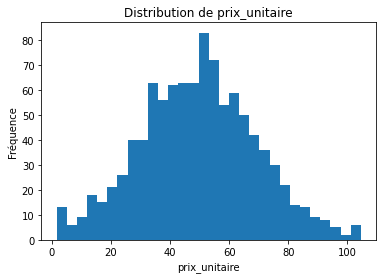

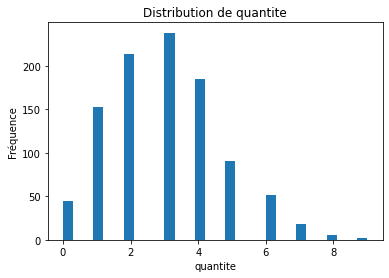

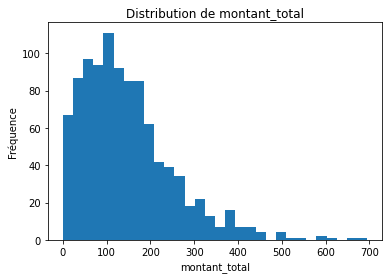

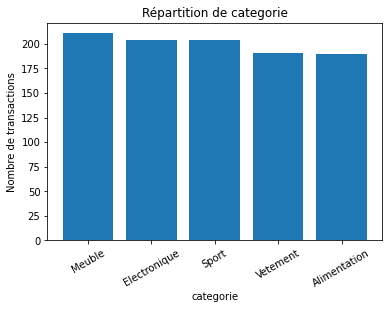

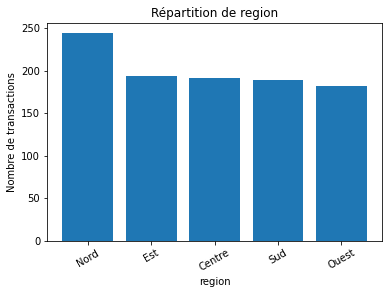

In [13]:
import matplotlib.pyplot as plt

df["date"] = pd.to_datetime(df["date"], errors="coerce")

numeric_cols = ["prix_unitaire", "quantite", "montant_total"]

for col in numeric_cols:
    plt.figure()
    plt.hist(df[col], bins=30)
    plt.title(f"Distribution de {col}")
    plt.xlabel(col)
    plt.ylabel("Fréquence")
    plt.show()

categorical_cols = ["categorie", "region"]

for col in categorical_cols:
    counts = df[col].value_counts()
    plt.figure()
    plt.bar(counts.index, counts.values)
    plt.title(f"Répartition de {col}")
    plt.xlabel(col)
    plt.ylabel("Nombre de transactions")
    plt.xticks(rotation=30)
    plt.show()



Exercice 3

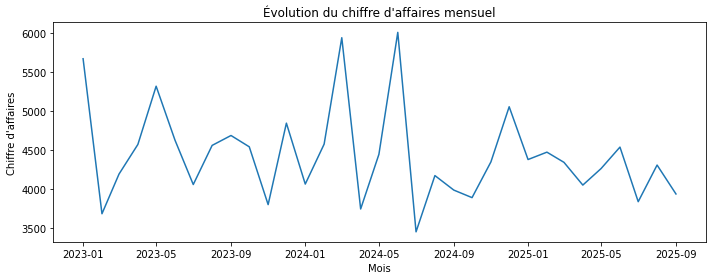

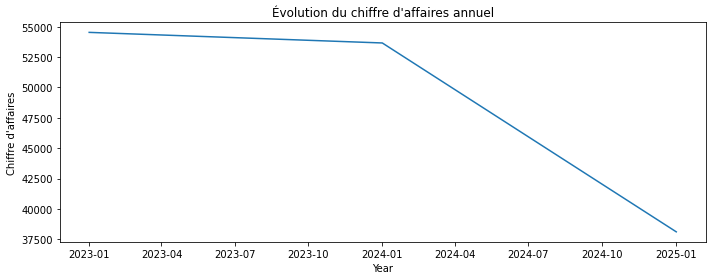

In [26]:
df["month"] = df["date"].dt.month
df["dayofweek"] = df["date"].dt.day_name()


df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
ca_mensuel = df.groupby("month")["montant_total"].sum()

plt.figure(figsize=(10,4))
plt.plot(ca_mensuel.index, ca_mensuel.values)
plt.title("Évolution du chiffre d'affaires mensuel")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires")
plt.tight_layout()
plt.show()

df["year"] = df["date"].dt.to_period("Y").dt.to_timestamp()
ca_mensuel = df.groupby("year")["montant_total"].sum()

plt.figure(figsize=(10,4))
plt.plot(ca_mensuel.index, ca_mensuel.values)
plt.title("Évolution du chiffre d'affaires annuel")
plt.xlabel("Year")
plt.ylabel("Chiffre d'affaires")
plt.tight_layout()
plt.show()


Exercice 4

In [22]:
import matplotlib.pyplot as plt

correlation_matrix = df.corr()
print(correlation_matrix)

               produit_id  prix_unitaire  quantite  client_id  montant_total  \
produit_id       1.000000      -0.041633  0.054516  -0.000840       0.021367   
prix_unitaire   -0.041633       1.000000 -0.029564   0.042275       0.535673   
quantite         0.054516      -0.029564  1.000000  -0.001015       0.766617   
client_id       -0.000840       0.042275 -0.001015   1.000000       0.032110   
montant_total    0.021367       0.535673  0.766617   0.032110       1.000000   
month_num        0.009722       0.008496 -0.027026   0.029356      -0.026334   

               month_num  
produit_id      0.009722  
prix_unitaire   0.008496  
quantite       -0.027026  
client_id       0.029356  
montant_total  -0.026334  
month_num       1.000000  


Hypothèse

1. Certaines catégories se vendent mieux dans certaines régions


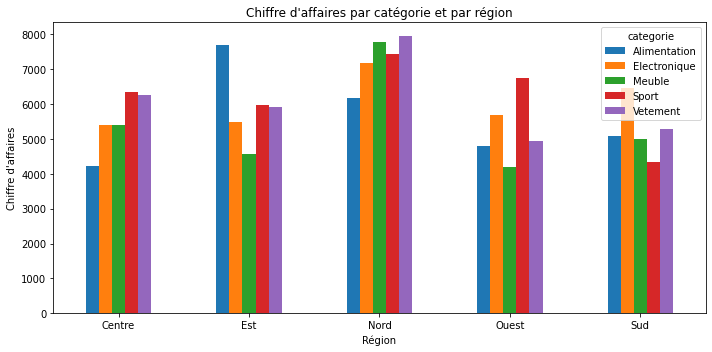

In [21]:
cat_region_ca = (
    df.groupby(["region", "categorie"])["montant_total"]
    .sum()
    .unstack()
)

cat_region_ca.plot(kind="bar", figsize=(10,5))
plt.title("Chiffre d'affaires par catégorie et par région")
plt.xlabel("Région")
plt.ylabel("Chiffre d'affaires")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

D'après le graphique, la catégorie Alimentation se vend bien mieux dans l'Est et la catégirue Meuble et Vetement se vend mieux dans le Noes

2. Il existe des saisonnalités dans les ventes


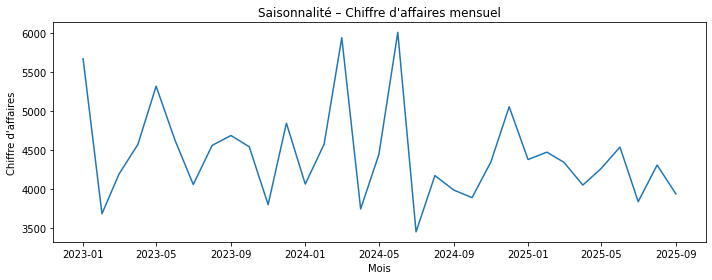

In [23]:
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
ca_mensuel = df.groupby("month")["montant_total"].sum()

plt.figure(figsize=(10,4))
plt.plot(ca_mensuel.index, ca_mensuel.values)
plt.title("Saisonnalité – Chiffre d'affaires mensuel")
plt.xlabel("Mois")
plt.ylabel("Chiffre d'affaires")
plt.tight_layout()
plt.show()

D'après cette courbe, on peut déterminer une certaine saisonalité 
car le chiffre d'affaires n'est pas stable. On peut observer des pics et des creux. 

3. Le prix n'influence pas la quantité vendue


In [24]:
import matplotlib.pyplot as plt

correlation_matrix = df.corr()
print(correlation_matrix)

               produit_id  prix_unitaire  quantite  client_id  montant_total  \
produit_id       1.000000      -0.041633  0.054516  -0.000840       0.021367   
prix_unitaire   -0.041633       1.000000 -0.029564   0.042275       0.535673   
quantite         0.054516      -0.029564  1.000000  -0.001015       0.766617   
client_id       -0.000840       0.042275 -0.001015   1.000000       0.032110   
montant_total    0.021367       0.535673  0.766617   0.032110       1.000000   
month_num        0.009722       0.008496 -0.027026   0.029356      -0.026334   

               month_num  
produit_id      0.009722  
prix_unitaire   0.008496  
quantite       -0.027026  
client_id       0.029356  
montant_total  -0.026334  
month_num       1.000000  


La corrélation entre prix_unitaire et quantite est de -0,0296.
Cette valeur est très proche de 0, ce qui indique une absence de relation linéaire significative entre le prix unitaire et la quantité vendue.